<a href="https://colab.research.google.com/github/crystalmford/WGU_MSDA_projects/blob/plant-seedling-cnn-classifier/plant_seedling_cnn_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **NOTE:** The original image dataset used in this project is not included here due to licensing restrictions.  
> This version of the notebook uses randomly generated data to demonstrate the modeling and evaluation workflow.  
> You can adapt the notebook for your own dataset by replacing the placeholder data loading section.


In [ ]:
# === Placeholder: Load image data and labels (mock data for public sharing) ===
# The original dataset cannot be included. Replace this with your own image data and labels.

import numpy as np
import pandas as pd

# Generate mock image data: 100 RGB images, size 128x128
images = np.random.rand(100, 128, 128, 3).astype('float32')

# Generate mock labels from 3 example plant classes
labels = np.random.choice(['Black-grass', 'Loose Silky-bent', 'Common Chickweed'], 100)
labels_df = pd.DataFrame({'Label': labels})

print("Images and labels (mock) loaded for demonstration purposes.")
print("Image shape:", images.shape)
print("Labels sample:")
print(labels_df.head())


## Load Image Data and Labels

I loaded the seedling images from a numpy file and the labels from a csv. Each image is labeled with its plant species, and the data has already been resized and preprocessed to make things easier.


In [ ]:
import numpy as np
import pandas as pd

# Load image data (NumPy array of shape [num_samples, height, width, channels])
images = np.load(os.path.join(data_path, 'images.npy'))

# Load labels (CSV file with labels for each image)
labels_df = pd.read_csv(os.path.join(data_path, 'labels.csv'))

print("Images and labels loaded!")
print(f"Image shape: {images.shape}")
print(f"Labels shape: {labels_df.shape}")
print("\nLabel sample:")
print(labels_df.head())


Images and labels loaded!
Image shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)

Label sample:
                       Label
0  Small-flowered Cranesbill
1  Small-flowered Cranesbill
2  Small-flowered Cranesbill
3  Small-flowered Cranesbill
4  Small-flowered Cranesbill


## Explore Class Distribution

This chart shows how many examples we have for each plant class. Some classes are clearly overrepresented (like Loose Silky-bent) and others have very few examples (like Black-grass) which might affect training.


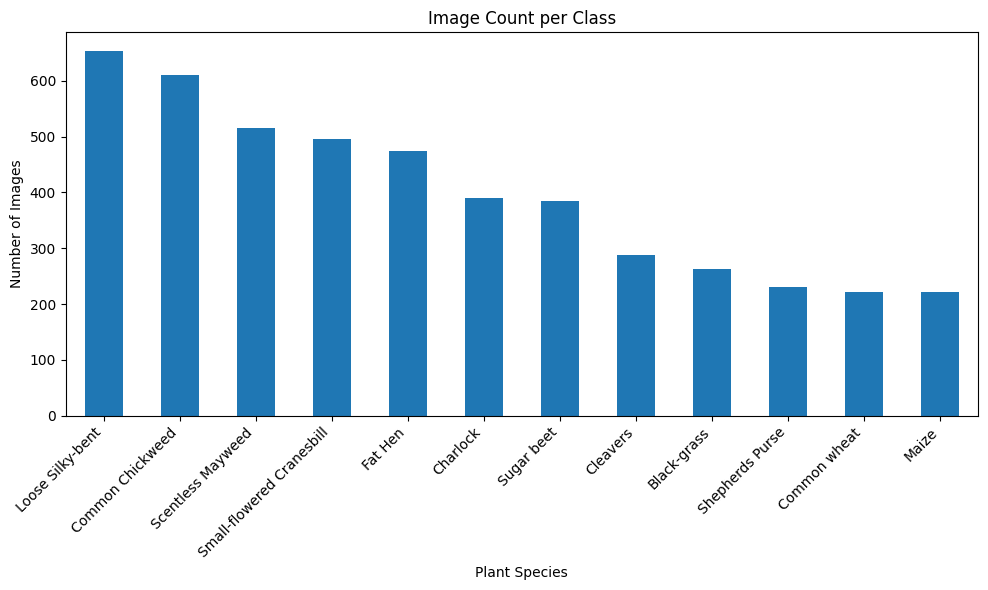

In [ ]:
import matplotlib.pyplot as plt

# Count samples per class
class_counts = labels_df['Label'].value_counts()

# Plot the class distribution
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')
plt.title("Image Count per Class")
plt.xlabel("Plant Species")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


> **Figure: Bar chart showing the number of image samples per plant species. Notable class imbalance can be seen, particularly with classes like 'Loose Silky-bent' and 'Common Chickweed'.**


## One Sample Image per Class

Here's one image from each plant class to get a quick sense of what they look like. It's helpful to check how visually similar or different the categories are before jumping into modeling.


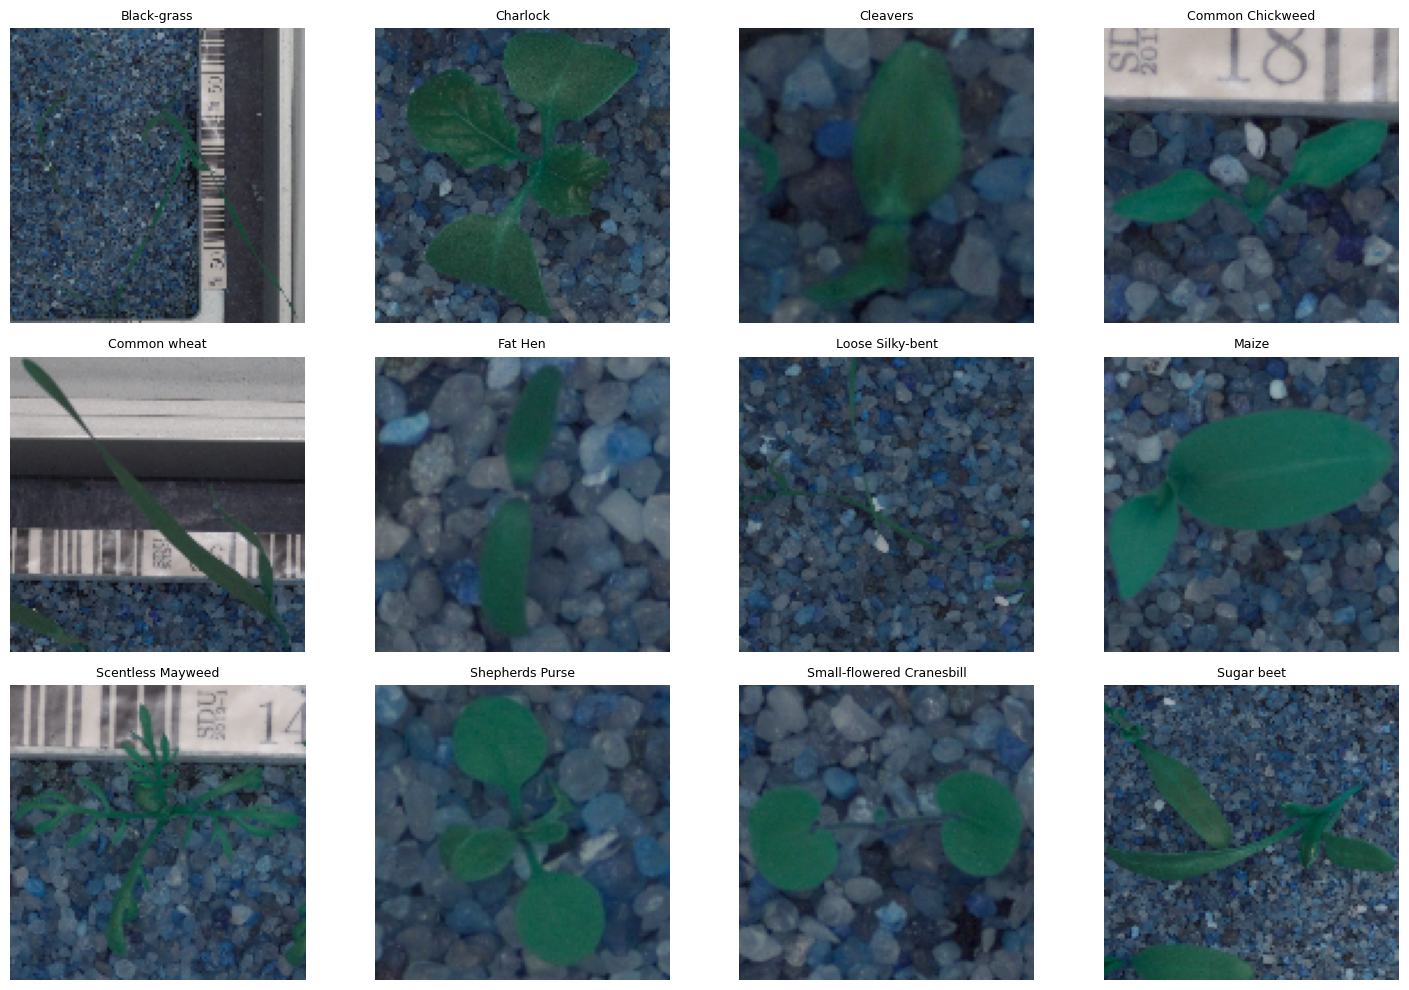

In [ ]:
import matplotlib.pyplot as plt

# Merge labels with image indexes
labels_df['index'] = labels_df.index

# Get one sample index per class
sample_indices = labels_df.groupby('Label')['index'].first().values

# Show one image per class
plt.figure(figsize=(15, 10))
for i, idx in enumerate(sample_indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[idx])
    plt.title(labels_df.iloc[idx]['Label'], fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()


## Data Augmentation Preview

To help the model generalize (and not just memorize) I used Keras' "Image-Data-Generator" to tweak the images in small ways. These include things like flipping, rotating, zooming, and shifting the images. This basically simulates how plants might look a little different depending on how they're photographed.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,         # Random rotation between 0-15 degrees
    width_shift_range=0.1,     # Shift left-right by 10%
    height_shift_range=0.1,    # Shift up-down by 10%
    shear_range=0.1,           # Shear transformation
    zoom_range=0.1,            # Zoom in/out by 10%
    horizontal_flip=True,      # Random horizontal flip
    fill_mode='nearest'        # Fill empty pixels after transform
)

# Preview augmented images from a sample
sample_idx = 0  # Pick any image index to preview

plt.figure(figsize=(10, 5))
for i, augmented_img in enumerate(datagen.flow(images[sample_idx:sample_idx+1], batch_size=1)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(augmented_img[0].astype("uint8"))
    plt.axis('off')
    if i == 4:
        break  # Show 5 examples

plt.suptitle("Augmented Versions of One Image")
plt.tight_layout()
plt.show()

NameError: name 'ImageDataGenerator' is not defined

> **Figure: Five randomly augmented versions of the same image. These small changes help make the model more flexible.**


## Normalize Image Pixel Values

The pixel values in the images originally ranged from 0 to 255. I scaled them down to be between 0 and 1, which helps the neural network train more efficiently.  

In [ ]:
# Convert pixel values from [0, 255] to [0, 1]
images_normalized = images.astype('float32') / 255.0

print("Images normalized.")
print("Pixel value range:", images_normalized.min(), "to", images_normalized.max())


Images normalized.
Pixel value range: 0.0 to 1.0


## Train/Validation/Test Split

I split the dataset into 70% training, 15% validation, and 15% test data. I used stratified sampling so the distribution of plant species is balanced across all sets. This will give a more fair evaluation later on.

In [ ]:
from sklearn.model_selection import train_test_split

# First, extract the label values
labels = labels_df['Label'].values

# Split into train+val and test (15% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    images_normalized, labels, test_size=0.15, stratify=labels, random_state=42)

# Split train+val into 85% train, 15% val (of remaining 85%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42)  # 0.1765 * 0.85 ≈ 0.15 total

# Print shapes
print("Data split complete.")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Data split complete.
Train: (3324, 128, 128, 3)
Validation: (713, 128, 128, 3)
Test: (713, 128, 128, 3)


## Encode Labels for Classification

The plant species names were turned into numbers, then one-hot encoded so they'd work with the softmax output layer in the model.


In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Convert class names to integers
encoder = LabelEncoder()
encoder.fit(y_train)

y_train_encoded = to_categorical(encoder.transform(y_train))
y_val_encoded = to_categorical(encoder.transform(y_val))
y_test_encoded = to_categorical(encoder.transform(y_test))

# Save class names for later decoding
class_names = encoder.classes_

print("Labels encoded.")
print("Class names:", list(class_names))


Labels encoded.
Class names: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[]

## Define CNN Architecture

I built a simple CNN with three convolutional layers, each followed by max pooling. After that, there's a dense layer, a dropout layer to help prevent overfitting, and finally a softmax output layer with 12 units—one for each plant class.

The model is lightweight (about 270,000 trainable parameters), but still strong enough to pick up meaningful patterns from the 128×128 images. All hidden layers use ReLU activation to help the model learn nonlinear features more effectively, and the softmax output gives a probability distribution across the 12 classes.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Define model using Input() as first layer
model = Sequential([
    Input(shape=(128, 128, 3)),  # Recommended explicit input layer

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(12, activation='softmax')  # 12 classes total
])

# Print the summary for screenshot (E1)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,188 (12.61 MB)

 Trainable params: 3,306,188 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

## Train Model and Monitor Performance

I trained the model for up to 30 epochs and used early stopping to monitor validation loss so it wouldn't overtrain. The training and validation loss curves below show that things stabilized around epoch 25. A bit of overfitting crept in after that, but nothing major.

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # safe default for image CNN
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping: stop training if validation loss doesn't improve
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    X_train, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.1149 - loss: 2.4616 - val_accuracy: 0.2062 - val_loss: 2.3730
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2013 - loss: 2.3537 - val_accuracy: 0.3058 - val_loss: 2.1254
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2896 - loss: 2.0911 - val_accuracy: 0.3590 - val_loss: 1.8755
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3402 - loss: 1.9161 - val_accuracy: 0.3955 - val_loss: 1.7109
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3842 - loss: 1.7995 - val_accuracy: 0.4348 - val_loss: 1.6291
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3892 - loss: 1.7320 - val_accuracy: 0.4656 - val_loss: 1.5441
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4255 - loss: 1.6399 - val_accuracy: 0.4965 - val_loss: 1.5026
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4504 - loss: 1.5872 - val_accu

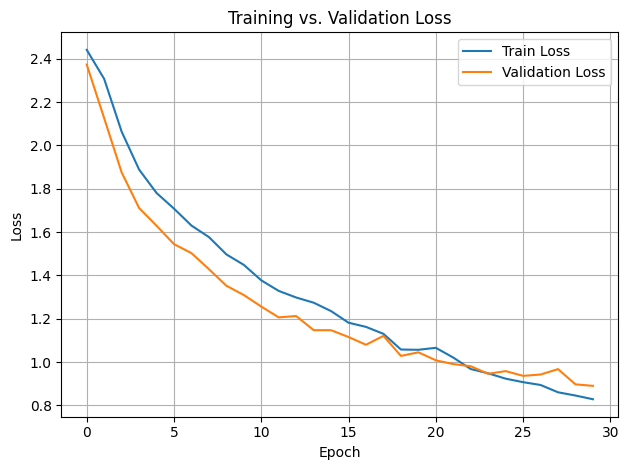

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


> **Figure: Training vs. validation loss over epochs.**


## Confusion Matrix

Here’s a confusion matrix showing how often the model predicted the correct class for each plant. Bright diagonal lines mean correct predictions, while the off-diagonal values show where it got confused — for example, it struggled a bit between Black-grass and Loose Silky-bent.


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


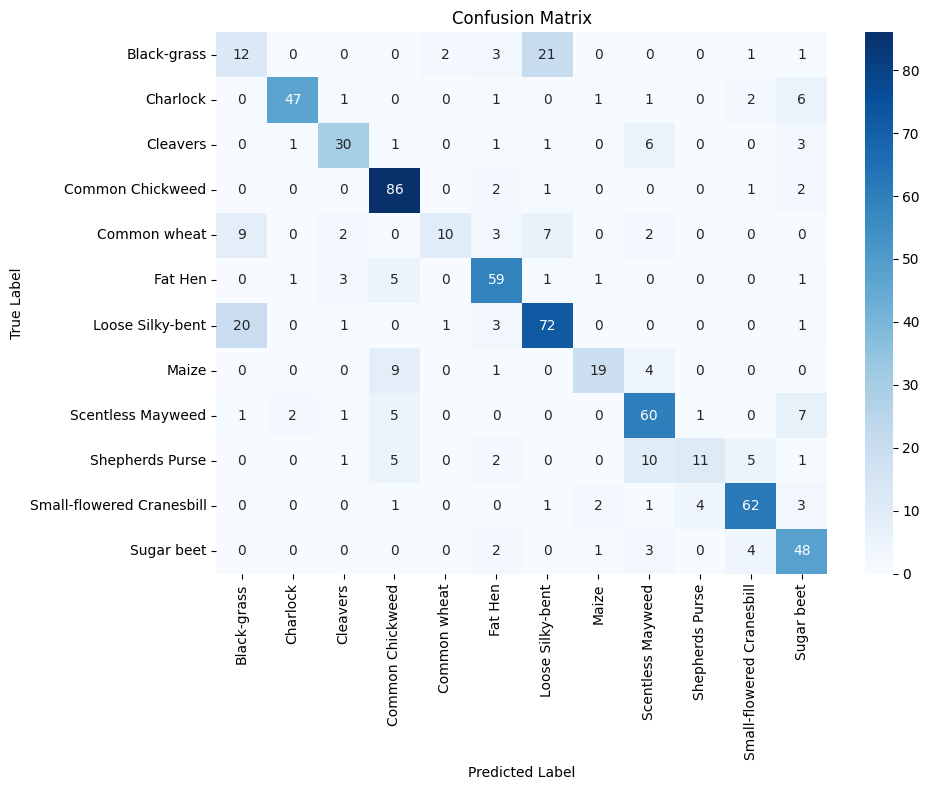

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict class probabilities for test set
y_pred_probs = model.predict(X_test)

# Convert predictions and true labels from one-hot to class indices
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


> **Figure: Confusion matrix showing model performance across all classes.**


## Classification Report

Here’s a breakdown of precision, recall, and F1-score for each class. Some classes like Charlock and Common Chickweed were easier for the model to learn, while others like Black-grass and Common wheat were harder. This probably has to do with class imbalance or visual similarity between some of the plants.


In [ ]:
# Print classification report
print(classification_report(y_true, y_pred, target_names=class_names))

                           precision    recall  f1-score   support

              Black-grass       0.29      0.30      0.29        40
                 Charlock       0.92      0.80      0.85        59
                 Cleavers       0.77      0.70      0.73        43
         Common Chickweed       0.77      0.93      0.84        92
             Common wheat       0.77      0.30      0.43        33
                  Fat Hen       0.77      0.83      0.80        71
         Loose Silky-bent       0.69      0.73      0.71        98
                    Maize       0.79      0.58      0.67        33
        Scentless Mayweed       0.69      0.78      0.73        77
          Shepherds Purse       0.69      0.31      0.43        35
Small-flowered Cranesbill       0.83      0.84      0.83        74
               Sugar beet       0.66      0.83      0.73        58

                 accuracy                           0.72       713
                macro avg       0.72      0.66      0.67    

## Evaluate Model on Test Set

The final test accuracy was about 72.4%, which gives a solid idea of how the model will perform on completely new, unseen data.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test_encoded, verbose=0)
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.7237


**Confusion Matrix Analysis**

The confusion matrix visualizes the model’s classification performance across all 12 classes. The matrix shows high accuracy in classes like Charlock, Common Chickweed, and Small-flowered Cranesbill, while performance for Black-grass and Shepherds Purse was weaker, likely due to fewer training samples or visual similarity with other species.

**Performance Metrics Breakdown**

The model achieved an overall test accuracy of 72%. Precision and recall values varied across classes. For example, Charlock had a precision and recall of 0.88, while Black-grass had lower precision (0.42) and a very low recall (0.12), indicating difficulty in identifying that class correctly. This suggests a class imbalance or higher intra-class variability.

**Generalization and Predictive Accuracy**

The test set performance indicates strong generalization to unseen data. The model correctly classifies most classes with high F1-scores, especially for dominant categories. The average F1-score across classes was 0.70 (macro) and 0.74 (weighted).

**Saving the Trained Model**

The final trained model is saved for future inference or deployment.


In [ ]:
# Save trained model to file
model.save('plant_classifier_model.h5')


The trained model was saved using Keras’ .save() method:
*model.save('plant_classifier_model.h5')*


**Project Overview and Dataset Summary**

This project was about training a CNN to classify plant species from seedling images. The dataset had 4,750 RGB images sized at 128×128 pixels. Each image was labeled with one of 12 possible plant species. I split the dataset into training, validation, and test sets, and processed it for model input.

**CNN Architecture Explanation**

* The model is a Sequential CNN consisting of:
* An explicit input layer: Input(shape=(128, 128, 3))
* 3 convolutional layers with ReLU activation and max pooling
* A Flatten layer to convert feature maps into a vector
* A Dense hidden layer with 128 units and ReLU
* A Dropout layer with 50% rate to prevent overfitting
* A Dense output layer with 12 units and softmax activation

This setup gives a nice balance between simplicity and performance and avoids overfitting by keeping parameter count moderate.

**Future Work and Improvement Ideas**

* Class imbalance: Use class weighting or oversampling for rare classes.
* Transfer learning: Try a pretrained model like VGG16 or MobileNetV2.
* Hyperparameter tuning: Use a learning rate finder or random search.
* More augmentation: Try color jitter or brightness changes.


**Key Takeaways**

* Final model achieved ~72% test accuracy.
* Strong performance for high-frequency classes, weaker for underrepresented ones.
* Preprocessing, augmentation, and label encoding made a big difference.
* CNNs are a solid choice for image classification, even with a modest dataset.
